# Risk Factors Contributing to Heart Attack
This project aims to analyze key risk factors contributing to heart attacks using patient health data. The objective is to identify important variables and build a predictive model for classification.

In [253]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

### Load Dataset
The dataset import to a pandas DataFrame to analysis.

In [255]:
file_path = r'C:\Users\paton\Downloads\Medicaldataset.csv'
df = pd.read_csv(file_path)

### Data Overview
Exploration of dataset including the number of rows, columns, data types and missing values.

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [259]:
df.shape

(1319, 9)

In [261]:
df.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [263]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [265]:
df['Result'] = df['Result'].map({'negative':0,'positive':1})

In [267]:
X = df[['Age','Gender','Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin']]

In [269]:
features = df.keys()

## Data Preprocessing
Data cleaning was performed to handle missing values and detect outliers. Outliers were identified using the IQR method. For medical features such as CK-MB and Troponin, extreme values were retained as they may represent critical conditions.

In [271]:
q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
IQR = q3-q1 
lower = q1-1.5*IQR 
upper = q3+1.5*IQR
outliers = (X < lower) | (X > upper)
mask = outliers.any(axis=1)
print("Outliers :\n", outliers.sum().to_string())

Outliers :
 Age                           7
Gender                        0
Heart rate                   30
Systolic blood pressure      32
Diastolic blood pressure     12
Blood sugar                  92
CK-MB                       205
Troponin                    257


In [273]:
df_cleaned = df[~mask]
X = df_cleaned[['Age','Gender','Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin']]
y = df_cleaned['Result']
df_cleaned

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
2,55,1,64,160,77,270.0,1.99,0.003,0
5,58,0,61,112,58,87.0,1.83,0.004,0
6,32,0,40,179,68,102.0,0.71,0.003,0
8,44,0,60,154,81,135.0,2.35,0.004,0
...,...,...,...,...,...,...,...,...,...
1311,85,1,112,115,69,114.0,2.19,0.062,1
1312,48,1,84,118,68,96.0,5.33,0.006,0
1313,86,0,40,179,68,147.0,5.22,0.011,0
1314,44,1,94,122,67,204.0,1.63,0.006,0


In [275]:
scaler = StandardScaler()

In [277]:
X_cleaned = scaler.fit_transform(X)

## Model Building
A Logistic Regression model was developed to classify the likelihood of heart attack occurrence. Feature scaling was applied to improve model performance.

In [279]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.3, random_state=42)

In [281]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Model Evaluation
Model performance was evaluated using accuracy score and confusion matrix. A heatmap was used to visualize classification results and assess prediction performance.

In [283]:
print (accuracy_score(y_test,y_pred))

0.9367088607594937


In [285]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       143
           1       0.93      0.90      0.92        94

    accuracy                           0.94       237
   macro avg       0.94      0.93      0.93       237
weighted avg       0.94      0.94      0.94       237



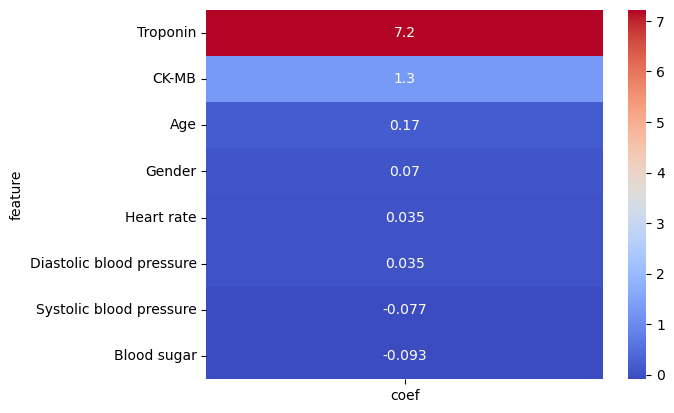

In [287]:
coef = model.coef_[0]

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coef': coef
})

feature_importance = feature_importance.sort_values(by='coef', ascending=False)

sns.heatmap(feature_importance.set_index('feature'), annot=True, cmap='coolwarm')
plt.show()

## Conclusion
The analysis shows that medical indicators such as Troponin and CK-MB play a significant role in predicting heart attacks. The Logistic Regression model provides a baseline for classification and can be further improved with advanced techniques.